In [1]:
import os
import numpy as np
import yaml

from ase.io import read,write
from ase import units
from rdkit.Chem import Draw

from openmm.openmm import XmlSerializer
from openmm.app import PME
from openmm.app.forcefield import ForceField
from openmm.app.pdbfile import PDBFile

from imolcryff.asemol import asemol_wrapper, pdb2packmol
from imolcryff.molinfo import Mol_Info
from imolcryff.g16wrapper import molinfo_setg16opt, molinfo_setg16charge
from imolcryff.gaffil_generators import GAFFilTemplateGenerator

In [2]:
def get_density(atoms):
    rho = atoms.get_masses().sum() / atoms.get_volume()
    rho *= units.m**3 / units.kg
    return rho

In [3]:
pdbfiles = ["FSA.pdb", "SN.pdb", "Li.pdb"]
Nmols = [80,160,80]
b, a, m = pdb2packmol(pdbfiles, Nmols, desired_density=1400, outfile="merge.pdb")


################################################################################

 PACKMOL - Packing optimization for the automated generation of
 starting configurations for molecular dynamics simulations.
 
                                                              Version 20.15.1 

################################################################################

  Packmol must be run with: packmol < inputfile.inp 

  Userguide at: http://m3g.iqm.unicamp.br/packmol 

  Reading input file... (Control-C aborts)
  Types of coordinate files specified: pdb
  Seed for random number generator:         6728
  Output file: packmol_tmp.pdb
  Reading coordinate file: atoms_0.pdb
  Reading coordinate file: atoms_1.pdb
  Reading coordinate file: atoms_2.pdb
  Number of independent structures:            3
  The structures are: 
  Structure            1 :atoms_0.pdb(           9  atoms)
  Structure            2 :atoms_1.pdb(          10  atoms)
  Structure            3 :atoms_2.pdb(           

In [4]:
pdb = PDBFile("merge.pdb")
atomlist_openmm = [a for a in pdb.topology.atoms()]
for bond in b:
    a1 = atomlist_openmm[bond[0]]
    a2 = atomlist_openmm[bond[1]]
    pdb.topology.addBond(a1, a2)
pdb.writeFile(pdb.topology, pdb.positions, open("merge_bonds.pdb", "w"))
at = read("merge_bonds.pdb")
get_density(at)

1399.9698034952273

In [5]:
params = yaml.safe_load(open('system_params.yml'))
params

{'g16opt': {'basis': '6-311++g(d,p)',
  'mem': '32GB',
  'method': 'wb97xd',
  'nprocshared': 32,
  'opt': 'maxcycle=256'},
 'charge': {'basis': '6-31g(d)',
  'algo': 'resp',
  'mem': '32GB',
  'method': 'hf',
  'nprocshared': 32},
 'ff_params': {'fftype': 'gaff-2.1',
  'iontype': 'amber/ions/ionsff99_tip3p.xml',
  'charge_scale_ion': 0.6,
  'charge_scale_neutral': 1.0}}

In [6]:
params["g16opt"]['nprocshared'] = 8
params["g16opt"]["mem"] = "32GB"

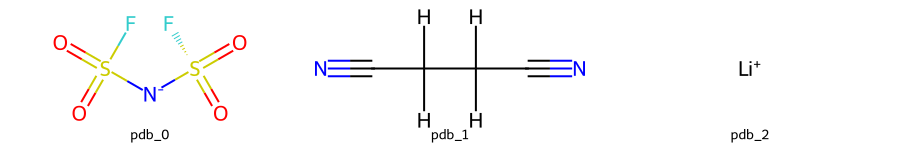

In [7]:
mol_info = Mol_Info()
for i, atoms in enumerate(a):
    mol_info.append_fromAtomsList([atoms],f"pdb_{i}",Nmols=Nmols[i])

mol_info.auto_charge_assign()
mol_info.get_rdkitmol()
mol_info.get_smiles_from_molinfo()

mol_info.il_assign()
mol_info.get_sdf_from_molinfo()
rdkitmol_list = [mol_info.mol_info[key]["rdkitmol2d"] for key in mol_info.mol_info.keys()]
Draw.MolsToGridImage(rdkitmol_list, molsPerRow = 3, subImgSize = (300,150),
                     legends = [molkey for molkey in mol_info.mol_info.keys()], maxMols = 60)

<div class="alert alert-danger">

***Caution!!!!!!!***  

</div>
The below block requires Gaussian 16 enviroment.   

Geometry optimizations and charge calculations are performed, which is time-consuming....  

If you want to skip the Gaussian 16 calculations, please don't run one block down and please run two blocks down.

In [8]:
molinfo_setg16opt(mol_info.mol_info, params["g16opt"])
mol_info.do_geoopt() # Gaussian16 is necessary
mol_info.load_geoopt_results()
molinfo_setg16charge(mol_info.mol_info, params["charge"])
mol_info.do_charge(force=True) # Gaussian16 is necessary

Skip pdb_0/pdb_0_0.log
Skip pdb_1/pdb_1_0.log
Skip pdb_2/pdb_2_0.log
g16charge -- pdb_0
g16 < pdb_0/pdb_0_charge.com  > pdb_0/pdb_0_charge.log

g16charge -- pdb_1
g16 < pdb_1/pdb_1_charge.com  > pdb_1/pdb_1_charge.log

g16charge -- pdb_2
g16 < pdb_2/pdb_2_charge.com  > pdb_2/pdb_2_charge.log



In [9]:
# If you want to skip the Gaussian16 calculations, you can load the results from the previous calculations.
# import glob
# for mol in mol_info.mol_info.keys():
#     g16logs = glob.glob(f"#{mol}#/*.log")
#     g16optlogs = [log for log in g16logs if "charge" not in log]
#     g16chargelog = [log for log in g16logs if "charge" in log][0]
#     mol_info.load_geoopt_results(g16optlogs, mol)
#     mol_info.mol_info[mol]["aseatoms_list"] = [read(log) for log in g16optlogs]
#     mol_info.mol_info[mol]["Natoms"] = len(read(g16optlogs[0]))

# molinfo_setg16charge(mol_info.mol_info, params["charge"])

In [10]:
for i in range(10):
    try:
        _ = mol_info.get_charges_from_molinfo()
    except:
        pass

dict_keys(['pdb_0', 'pdb_1', 'pdb_2'])
pdb_0
antechamber -i pdb_0/pdb_0_charge.log -fi gout -o pdb_0/resp_charge.mol2 -fo mol2 -at sybyl -c resp -nc -1 -pf y -dr no

Welcome to antechamber 22.0: molecular input file processor.

Info: The atom type is set to sybyl; the options available to the -at flag are
      gaff, gaff2, amber, bcc, and sybyl.

Info: Bond types are assigned for valence state (1) with penalty (1).




pdb_1
antechamber -i pdb_1/pdb_1_charge.log -fi gout -o pdb_1/resp_charge.mol2 -fo mol2 -at sybyl -c resp -nc 0 -pf y -dr no

Welcome to antechamber 22.0: molecular input file processor.

Info: The atom type is set to sybyl; the options available to the -at flag are
      gaff, gaff2, amber, bcc, and sybyl.





pdb_2
pdb_2/single_charge.mol2
dict_keys(['pdb_0', 'pdb_1', 'pdb_2'])
pdb_0
antechamber -i pdb_0/pdb_0_charge.log -fi gout -o pdb_0/resp_charge.mol2 -fo mol2 -at sybyl -c resp -nc -1 -pf y -dr no

Welcome to antechamber 22.0: molecular input file processor.

Inf

In [11]:
mol_info.adjust_charges(params["ff_params"])

5.999999997952088e-07
Net charge of pdb_0 is -0.6 and total charge is -0.5999994000000002
2.0000000000575113e-06
Net charge of pdb_1 is 0 and total charge is 2.0000000000575113e-06
0.0


In [12]:
mol_info.save_molinfo() # save the mol_info as mol_info.pkl files 

In [29]:
mmm = mol_info.get_molecule_omm()

if params["ff_params"]["fftype"].split("-")[0] == "gaff":
    gaff = GAFFilTemplateGenerator(molecules=mmm, forcefield=params["ff_params"]["fftype"]) # , il_assign=params["fsa_assign"])

forcefield = ForceField(params["ff_params"]["iontype"])
forcefield.registerTemplateGenerator(gaff.generator)

[11:52:45] atom 8 has specified valence (1) smaller than the drawn valence 2.


In [30]:
# Adjust Single-atom ion charge
for key in mol_info.mol_info.keys():
    natoms = mol_info.mol_info[key]["rdkitmol"].GetNumAtoms()
    if natoms == 1:
        symbol = mol_info.mol_info[key]["rdkitmol"].GetAtoms()[0].GetSymbol()
        for elem in forcefield._templates.keys():
            p = forcefield._templates[elem]
            for at in p.atoms:
                if at.element.symbol == symbol:
                    at.parameters["charge"] = mol_info.mol_info[key]["charges"][0]

In [31]:
pdb = PDBFile("merge_bonds.pdb")

In [32]:
sys = forcefield.createSystem(pdb.topology, nonbondedMethod=PME)
with open('system.xml', 'w') as output:
    output.write(XmlSerializer.serialize(sys))

In [33]:
from openmm import app
from parmed.openmm import load_topology

parm_top = load_topology(topology=pdb.topology, system=sys, xyz=pdb.positions)

parm_top.save('LIFSISN.top', overwrite=True)
parm_top.save('LIFSISN.gro', overwrite=True)

In [42]:
from openmm.app import HBonds

sys = forcefield.createSystem(pdb.topology, nonbondedMethod=PME)

In [46]:
from openff.interchange.components.mdconfig import MDConfig
from openff.toolkit import Topology
from openff.interchange.interop import openmm
from openff.interchange.interop.lammps.export import to_lammps

topology_off = Topology.from_openmm(pdb.topology, unique_molecules=mmm)
os.environ["INTERCHANGE_EXPERIMENTAL"] = "1"
a = openmm.from_openmm(system=sys, topology=topology_off, positions=pdb.getPositions())
to_lammps(a, "LIFSISN.data")